# Split Datasets

Split dataset to Train/Validation/Test sets

## A. Overview

Random split to Train, Validation and Test sets

## B. Combine Datasets

In [17]:
from pathlib import Path
import csv
import os
import random

from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

import configuration
from src import data_utils, setup

RANDS_STATE = 42
random.seed(RANDS_STATE)

dataset_path = Path('..') / 'data'

### B.1. Load Datasets

In [18]:
disaster_frac = data_utils.get_data_disaster_fraction()
disaster_filepath = dataset_path / 'disaster' / str(disaster_frac)

df_disaster_informative = pd.read_csv(disaster_filepath / 'informative.csv')
df_disaster_informative['subset'] = 'disaster'
# df_disaster_humanitarian = pd.read_csv(disaster_filepath / 'humanitarian.csv')
# df_disaster_humanitarian['subset'] = 'disaster'

In [19]:
extended_filepath = dataset_path / "extended"

df_weather = pd.read_csv(
    extended_filepath / str(data_utils.get_data_weather_fraction()) / "weather.csv"
)["tweet_text"].to_frame()
df_weather["informative"] = False
df_weather["subset"] = "weather"

df_out_topic = pd.read_csv(
    extended_filepath / str(data_utils.get_data_out_topic_fraction()) / "out_topic.csv"
)["tweet_text"].to_frame()
df_out_topic["informative"] = False
df_out_topic["subset"] = "out_topic"

### B.2. Combine Datasets

In [20]:
df_informative = (
    pd.concat([df_disaster_informative, df_weather, df_out_topic], ignore_index=True)
    .sample(frac=1, random_state=setup.RANDOM_SEED)
    .reset_index(drop=True)
)
df_informative.head()

,tweet_text,informative,subset
0,"#BotaniClean for #Harvey and #Irma clean up, C...",True,disaster
1,KAMALA HARRIS is taking advantage of the Ca fi...,True,disaster
2,How's that Global Warming treating you? Anyone...,False,weather
3,sismo Anoche #sismo mag. 3.8 en Maracaibo,True,disaster
4,Brezzzzzzyyy,False,out_topic


## C. Random split to Train, Validation and Test sets

### C.1. Splitting

Ratio: 70 - 15 - 15

In [21]:
df_train, df_validation = train_test_split(
    df_informative,
    test_size=0.3,
    random_state=setup.RANDOM_SEED,
    stratify=df_informative["informative"],
)
df_validation, df_test = train_test_split(
    df_validation, test_size=0.5, random_state=setup.RANDOM_SEED, stratify=df_validation["informative"]
)

print(len(df_train))
print(len(df_validation))
print(len(df_test))

# ration between train, validation, and test sets
total = len(df_train) + len(df_validation) + len(df_test)
print(f"Train: {len(df_train) / total:.2%}")
print(f"Validation: {len(df_validation) / total:.2%}")
print(f"Test: {len(df_test) / total:.2%}")

10224
2191
2191
Train: 70.00%
Validation: 15.00%
Test: 15.00%


In [22]:
data_frac = data_utils.DATA_FRACTION
split_path = dataset_path / "splited" / str(data_frac)
split_path.mkdir(parents=True, exist_ok=True)
df_train.to_csv(
    split_path / "informative_train.csv", index=False, quoting=csv.QUOTE_ALL
)

df_validation.to_csv(
    split_path / "informative_validation.csv", index=False,quoting=csv.QUOTE_ALL,
)

df_test.to_csv(
    split_path / "informative_test.csv", index=False, quoting=csv.QUOTE_ALL
)

### C.2. Review

#### Informative label

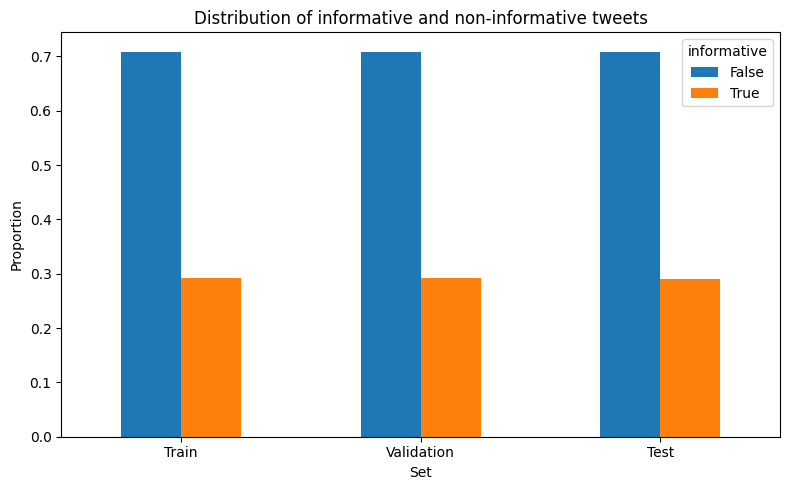

In [23]:
informative_dist = pd.DataFrame({
    "Train": df_train["informative"].value_counts(normalize=True).sort_index(),
    "Validation": df_validation["informative"].value_counts(normalize=True).sort_index(),
    "Test": df_test["informative"].value_counts(normalize=True).sort_index(),
}).fillna(0)

ax = informative_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_xlabel("Set")
ax.set_ylabel("Proportion")
ax.set_title("Distribution of informative and non-informative tweets")
ax.legend(title="informative")
plt.tight_layout()
plt.show()

#### Subset label

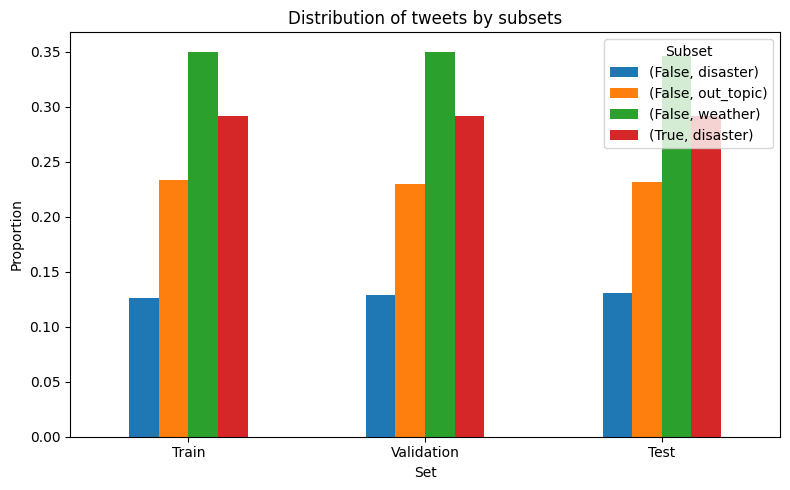

In [24]:
subset_dist = pd.DataFrame({
    "Train": df_train[["informative", "subset"]].value_counts(normalize=True).sort_index(),
    "Validation": df_validation[["informative", "subset"]].value_counts(normalize=True).sort_index(),
    "Test": df_test[["informative", "subset"]].value_counts(normalize=True).sort_index(),
}).fillna(0)

ax = subset_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_xlabel("Set")
ax.set_ylabel("Proportion")
ax.set_title("Distribution of tweets by subsets")
ax.legend(title="Subset")
plt.tight_layout()
plt.show()